In [1]:
from deap import tools, creator, base, algorithms, benchmarks
import pymop
from math import factorial
from numpy import random
from meamt_core import generate_dtlz3_front_random, calculate_igd_plus
import numpy
from deap.benchmarks.tools import hypervolume
import numpy as np

PROBLEM = "dtlz3"
NOBJ = 4
K = 10
NDIM = NOBJ + K - 1
P = 12
BOUND_LOW, BOUND_UP = 0.0, 1.0
pareto_real = generate_dtlz3_front_random(NOBJ, 1000)

In [2]:
MU = 800
NGEN = 600
CXPB = 1.0
MUTPB = 1.0

ref_points_hv = [1.1] * NOBJ
ref_points = tools.uniform_reference_points(NOBJ, P)


In [3]:
creator.create("FitnessMin", base.Fitness, weights=(-1.0,) * NOBJ)
creator.create("Individual", list, fitness=creator.FitnessMin)

def uniform(low, up, size=None):
    try:
        return [random.uniform(a, b) for a, b in zip(low, up)]
    except TypeError:
        return [random.uniform(a, b) for a, b in zip([low] * size, [up] * size)]

toolbox = base.Toolbox()
toolbox.register("attr_float", uniform, BOUND_LOW, BOUND_UP, NDIM)
toolbox.register("individual", tools.initIterate, creator.Individual, toolbox.attr_float)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

toolbox.register("evaluate", benchmarks.dtlz3, obj=NOBJ)
toolbox.register("mate", tools.cxSimulatedBinaryBounded, low=BOUND_LOW, up=BOUND_UP, eta=30.0)
toolbox.register("mutate", tools.mutPolynomialBounded, low=BOUND_LOW, up=BOUND_UP, eta=20.0, indpb=1.0/NDIM)
toolbox.register("select", tools.selNSGA3, ref_points=ref_points)

In [4]:
def main(seed=None):
    random.seed(seed)

    # Initialize statistics object
    stats = tools.Statistics(lambda ind: ind.fitness.values)
    stats.register("avg", numpy.mean, axis=0)
    stats.register("std", numpy.std, axis=0)
    stats.register("min", numpy.min, axis=0)
    stats.register("max", numpy.max, axis=0)

    logbook = tools.Logbook()
    logbook.header = "gen", "evals", "std", "min", "avg", "max", "hypervolume", "igd_plus"

    pop = toolbox.population(n=MU)

    # Evaluate the individuals with an invalid fitness
    invalid_ind = [ind for ind in pop if not ind.fitness.valid]
    fitnesses = toolbox.map(toolbox.evaluate, invalid_ind)
    for ind, fit in zip(invalid_ind, fitnesses):
        ind.fitness.values = fit

    # Compile statistics about the population
    record = stats.compile(pop)
    logbook.record(gen=0, evals=len(invalid_ind), **record)
    print(logbook.stream)

    # Begin the generational process
    for gen in range(1, NGEN):
        offspring = algorithms.varAnd(pop, toolbox, CXPB, MUTPB)

        # Evaluate the individuals with an invalid fitness
        invalid_ind = [ind for ind in offspring if not ind.fitness.valid]
        fitnesses = toolbox.map(toolbox.evaluate, invalid_ind)
        for ind, fit in zip(invalid_ind, fitnesses):
            ind.fitness.values = fit

        # Select the next generation population from parents and offspring
        pop = toolbox.select(pop + offspring, MU)

        # Compile statistics about the new population
        record = stats.compile(pop)
        pop_comp = pop[:(int)(MU/(1 << NOBJ))]
        hv_val = hypervolume(pop_comp, ref_points_hv)
        approx_front = np.array([ind.fitness.values for ind in pop])
        approx_front_comp = approx_front[:(int)(MU/(1 << NOBJ))]
        igd_plus_val = calculate_igd_plus(pareto_real, approx_front_comp)
        logbook.record(gen=gen, evals=len(invalid_ind), hypervolume=hv_val,igd_plus=igd_plus_val, **record)
        print(logbook.stream)

    return pop, logbook

In [5]:
pop, logbook = main()

gen	evals	std                                                  	min                                          	avg                                                  	max                                                      	hypervolume	igd_plus
0  	800  	[273.77532128 270.1063309  340.2591396  358.82764818]	[0.01243749 0.03883209 0.25483989 2.34884519]	[278.31522251 266.95380568 432.49346817 687.48760413]	[1327.48713662 1318.31909468 1538.70708001 1537.97802566]	           	        
1  	800  	[301.50338082 302.90905162 341.43524688 314.14625449]	[8.35304580e-03 2.55741115e-04 3.50919827e-03 4.80050298e-01]	[282.12586946 277.49697168 415.34441406 486.06017678]	[1370.38661413 1434.90847436 1538.70708001 1407.75496483]	0          	540.282 
2  	800  	[312.31440183 311.63900286 339.72991298 299.50313955]	[1.81099721e-04 2.55741115e-04 3.50919827e-03 4.80050298e-01]	[282.79434399 276.48746638 386.18745176 384.28301098]	[1377.96978615 1434.90847436 1538.70708001 1458.91546409]	0          	405.2

[2.856841107292528e-05, 0.8735078367858968, 0.005362473936484924, 0.5000091386388323, 0.4999587096052188, 0.4999629901706756, 0.5000376335420375, 0.5000039843609893, 0.5000025912475206, 0.5000058307195042, 0.4999882019452674, 0.49999414072848763, 0.5000238438828504]
[1.4038325516222643e-06, 0.3273576075074399, 0.09065040347497891, 0.49997680746180545, 0.4999896317958666, 0.5000564898523554, 0.49996659655442843, 0.49999425601028363, 0.5000288603515365, 0.49999380252818204, 0.5000077139429521, 0.4999950509765011, 0.500024946425958]
[0.2693511832041337, 0.3662554097591288, 0.3262287461777156, 0.4999803936329077, 0.49998986682609387, 0.4999430009621234, 0.4999521504322527, 0.4999950391926745, 0.5000336076406083, 0.49999567378017834, 0.4999883847953849, 0.5000020007272491, 0.5000077526120328]
[0.455017747008609, 0.2867387735528555, 0.8732657629735785, 0.49997180840387945, 0.4999536956250146, 0.5000468107692855, 0.5000554732040834, 0.4999972337607979, 0.5000122102389586, 0.5000290865062132, 

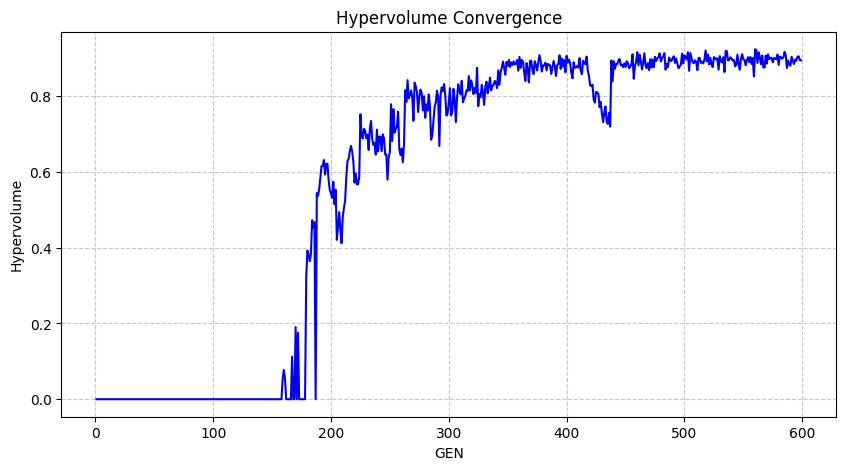

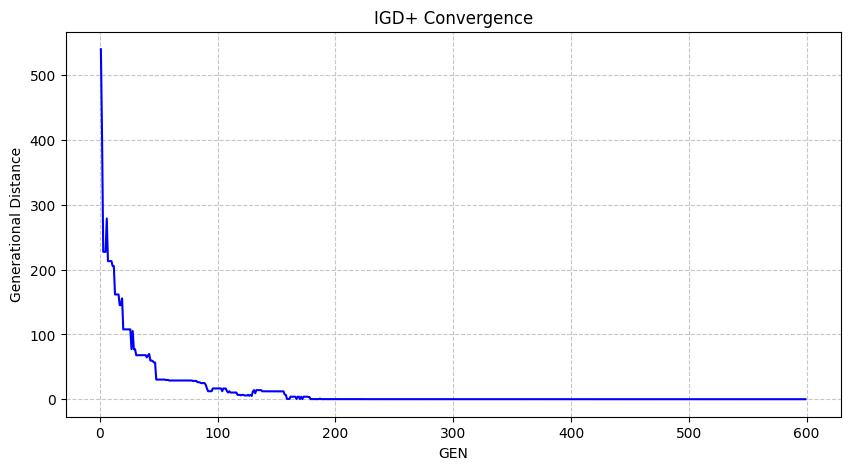

In [6]:
import matplotlib.pyplot as plt

for ind in pop:
   print(ind)

# Hypervolume Graphic
gen = logbook.select("gen")
fit_hv = logbook.select("hypervolume")
plt.figure(figsize=(10, 5))
plt.plot(gen, fit_hv, 'b-')
plt.title("Hypervolume Convergence")
plt.xlabel('GEN')
plt.ylabel('Hypervolume')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# IGD+ Graphic
gen = logbook.select("gen")
fit_igd = logbook.select("igd_plus")
plt.figure(figsize=(10, 5))
plt.plot(gen, fit_igd, 'b-')
plt.title("IGD+ Convergence")
plt.xlabel('GEN')
plt.ylabel('Generational Distance')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()